In [4]:
import pandas as pd

# 1. Use a raw string for the path
path = 'C:/Users/VEDANT/Desktop/ML-For-Beginners/2-Regression/data/US-pumpkins.csv'
pumpkins_data = pd.read_csv(path)

# 2. Use a faster string check (regex=False is default and faster)
# Added na=False to handle any potential empty cells safely
pumpkins_data = pumpkins_data[pumpkins_data['Package'].str.contains('bushel', case=True, regex=True)]

pumpkins_data.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [ ]:
pumpkins_data.isnull().sum()#Gives me the number of NaN in each column

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [6]:
final_columns = ['Package','Date','Low Price', 'High Price','Variety']
pumpkins_data = pumpkins_data.drop([c for c in pumpkins_data.columns if c not in final_columns], axis=1)
pumpkins_data.head()

,Package,Variety,Date,Low Price,High Price
70,1 1/9 bushel cartons,PIE TYPE,9/24/16,15.0,15.0
71,1 1/9 bushel cartons,PIE TYPE,9/24/16,18.0,18.0
72,1 1/9 bushel cartons,PIE TYPE,10/1/16,18.0,18.0
73,1 1/9 bushel cartons,PIE TYPE,10/1/16,17.0,17.0
74,1 1/9 bushel cartons,PIE TYPE,10/8/16,15.0,15.0


In [8]:
#Create new columns price and month then create a new dataframe which has those columns in addition
price=(pumpkins_data['Low Price']+pumpkins_data['High Price'])/2
Month=pd.DatetimeIndex(pumpkins_data['Date']).month
new_pumpkins=pd.DataFrame({'Month': Month, 'AvgPrice': price, 'Package': pumpkins_data['Package'],
                           'Variety': pumpkins_data['Variety']})
new_pumpkins.head()

,Month,AvgPrice,Package,Variety
70,9,15.0,1 1/9 bushel cartons,PIE TYPE
71,9,18.0,1 1/9 bushel cartons,PIE TYPE
72,10,18.0,1 1/9 bushel cartons,PIE TYPE
73,10,17.0,1 1/9 bushel cartons,PIE TYPE
74,10,15.0,1 1/9 bushel cartons,PIE TYPE


In [9]:
#now we divide the total price with the measure of pumpkins sold to get price per unit
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'AvgPrice']=price/(1+(1/9))

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'AvgPrice']=price/(1/2)

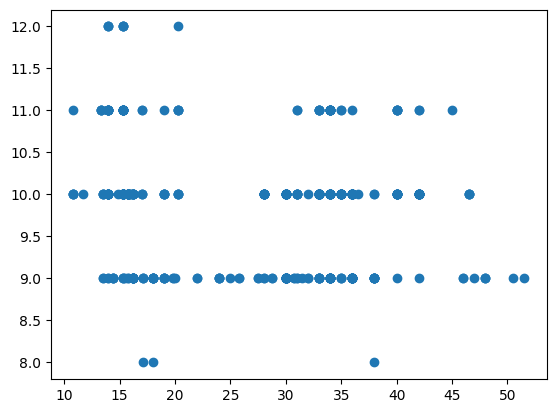

In [10]:
import matplotlib.pyplot as plt

Price=new_pumpkins.AvgPrice
Months=new_pumpkins.Month

plt.scatter(Price, Month)
plt.show()

Text(0, 0.5, 'Price of pumpkins at a month')

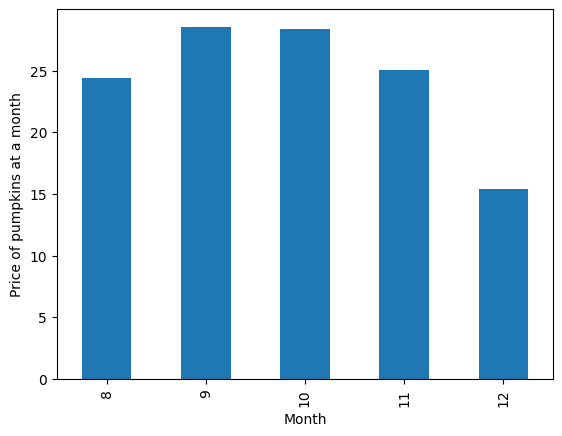

In [ ]:
#We use pandas API to plot a bar chart using .groupby().mean()
new_pumpkins.groupby(['Month'])['AvgPrice'].mean().plot(kind='bar')

plt.ylabel('Price of pumpkins at a month')
#From Bar chart we see that pumpkins are the cheapest in december(Month 12)